# Basic Environment Setup 

In [1]:
import torch
print(torch.cuda.is_available())
print(torch.cuda.get_device_name(0))

True
NVIDIA RTX 2000 Ada Generation


In [2]:
%pip install -q torchaudio soundfile matplotlib


[notice] A new release of pip is available: 24.2 -> 26.0.1
[notice] To update, run: python -m pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [3]:
import torchaudio
print(torchaudio.__version__)

2.4.1+cu124


# Dataset

In [4]:
import os
os.makedirs("./data", exist_ok=True)

dataset = torchaudio.datasets.SPEECHCOMMANDS("./data", download=True)
print(f"Total samples: {len(dataset)}")

100.0%


Total samples: 105829


In [5]:
# now try again
waveform, sample_rate, label, speaker_id, utterance_number = dataset[0]

print(f"Label: {label}")
print(f"Sample rate: {sample_rate}")
print(f"Waveform shape: {waveform.shape}")

Label: backward
Sample rate: 16000
Waveform shape: torch.Size([1, 16000])


In [6]:
import IPython.display as ipd

# Play the audio we just loaded
ipd.Audio(waveform, rate=sample_rate)

# Conert the audio to a mel spectrogram so that cnn can visualize it better

In [7]:
import torchaudio.transforms as T

# convert raw audio to mel spectrogram
mel_transform = T.MelSpectrogram(
    sample_rate=16000,  # our audio is 16kHz
    n_fft=400,          # window size for FFT
    hop_length=160,     # slide window by this many samples each time
    n_mels=64           # number of mel frequency bins
)

mel_spec = mel_transform(waveform)
print(f"Mel spectrogram shape: {mel_spec.shape}")

Mel spectrogram shape: torch.Size([1, 64, 101])


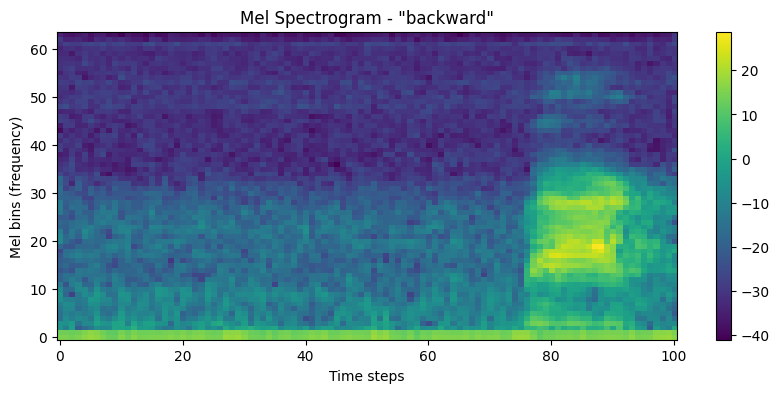

In [8]:
import matplotlib.pyplot as plt

# convert to log scale so it's easier to see (same as before in Stage 2)
import torch
mel_db = T.AmplitudeToDB()(mel_spec)

plt.figure(figsize=(10, 4))
plt.imshow(mel_db[0].numpy(), aspect='auto', origin='lower')
plt.title(f'Mel Spectrogram - "{label}"')
plt.ylabel('Mel bins (frequency)')
plt.xlabel('Time steps')
plt.colorbar()
plt.show()

# Bulid a CNN

In [9]:
import torch
import torch.nn as nn

class AudioCNN(nn.Module):
    def __init__(self, num_classes=35):
        super(AudioCNN, self).__init__()
        
        # CNN layer 1: 1 input channel, 32 kernels, each 3x3
        self.conv1 = nn.Conv2d(1, 32, kernel_size=3, padding=1)
        self.pool = nn.MaxPool2d(2, 2)  # max pooling, halves the size
        
        # CNN layer 2: 32 input channels, 64 kernels, each 3x3
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        
        # fully connected layer: 64 feature maps of size 16x25 → 35 classes
        self.fc = nn.Linear(64 * 16 * 25, num_classes)
        
        self.relu = nn.ReLU()  # activation function, ignore for now
    
    def forward(self, x):
        x = self.pool(self.relu(self.conv1(x)))  # conv1 → relu → pool
        x = self.pool(self.relu(self.conv2(x)))  # conv2 → relu → pool
        x = x.view(x.size(0), -1)               # flatten
        x = self.fc(x)                           # classify
        return x

# create the model
model = AudioCNN(num_classes=35)
print(model)

AudioCNN(
  (conv1): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (fc): Linear(in_features=25600, out_features=35, bias=True)
  (relu): ReLU()
)


In [10]:
# we already have mel_spec from before
# CNN expects shape [batch, channel, height, width]
# our mel_spec is [1, 64, 101] — add batch dimension to make it [1, 1, 64, 101]

input_tensor = mel_spec.unsqueeze(0)
print(f"Input shape: {input_tensor.shape}")

output = model(input_tensor)
print(f"Output shape: {output.shape}")
print(f"Output: {output}")

Input shape: torch.Size([1, 1, 64, 101])
Output shape: torch.Size([1, 35])
Output: tensor([[ 0.9121,  1.6501,  2.0100,  1.7473, -1.0339,  3.6128, -0.6250, -5.2255,
          2.8508, -1.1105, -0.3931,  0.7489,  3.0703, -1.0018,  0.2358,  0.3933,
          1.3206,  1.9189,  1.3951,  1.8942,  0.2501,  3.1085, -2.5221,  1.6807,
         -0.7357, -1.1476, -3.9284, -1.5656,  0.8465, -0.6248,  1.0396, -0.5826,
          0.1354,  2.3005, -2.4668]], grad_fn=<AddmmBackward0>)


# Dataset Preparation

In [11]:
# get all 35 unique words - these are our classes
import os
labels = sorted(os.listdir('./data/SpeechCommands/speech_commands_v0.02/'))
labels = [l for l in labels if not l.startswith('_') and '.' not in l]
print(f"Number of classes: {len(labels)}")
print(labels)

Number of classes: 36
['LICENSE', 'backward', 'bed', 'bird', 'cat', 'dog', 'down', 'eight', 'five', 'follow', 'forward', 'four', 'go', 'happy', 'house', 'learn', 'left', 'marvin', 'nine', 'no', 'off', 'on', 'one', 'right', 'seven', 'sheila', 'six', 'stop', 'three', 'tree', 'two', 'up', 'visual', 'wow', 'yes', 'zero']


In [12]:
# remove LICENSE from the list
labels = [l for l in labels if l != 'LICENSE']
print(f"Number of classes: {len(labels)}")
print(labels)

# create a dictionary: word → number
# CNN needs numbers not words
label_to_idx = {label: idx for idx, label in enumerate(labels)}
print(f"\nExample: 'backward' = {label_to_idx['backward']}")
print(f"Example: 'yes' = {label_to_idx['yes']}")

Number of classes: 35
['backward', 'bed', 'bird', 'cat', 'dog', 'down', 'eight', 'five', 'follow', 'forward', 'four', 'go', 'happy', 'house', 'learn', 'left', 'marvin', 'nine', 'no', 'off', 'on', 'one', 'right', 'seven', 'sheila', 'six', 'stop', 'three', 'tree', 'two', 'up', 'visual', 'wow', 'yes', 'zero']

Example: 'backward' = 0
Example: 'yes' = 33


In [13]:
from torch.utils.data import Dataset, DataLoader
import torch.nn.functional as F

class SpeechCommandsDataset(Dataset):
    def __init__(self, data, label_to_idx):
        self.data = data
        self.label_to_idx = label_to_idx
        self.mel_transform = T.MelSpectrogram(
            sample_rate=16000,
            n_fft=400,
            hop_length=160,
            n_mels=64
        )
        self.db_transform = T.AmplitudeToDB()
    
    def __len__(self):
        return len(self.data)
    
    def __getitem__(self, idx):
        waveform, sample_rate, label, _, _ = self.data[idx]
        
        # pad waveform to exactly 16000 samples if shorter
        if waveform.shape[1] < 16000:
            pad_amount = 16000 - waveform.shape[1]
            waveform = F.pad(waveform, (0, pad_amount))
        
        mel = self.mel_transform(waveform)
        mel = self.db_transform(mel)
        
        label_idx = self.label_to_idx[label]
        
        return mel, label_idx

# recreate everything with fixed dataset
full_dataset = SpeechCommandsDataset(dataset, label_to_idx)

train_size = int(0.8 * len(full_dataset))
test_size = len(full_dataset) - train_size
train_dataset, test_dataset = torch.utils.data.random_split(full_dataset, [train_size, test_size])

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

print("Dataset ready")

Dataset ready


In [14]:
import torch.optim as optim

# move model to GPU
device = torch.device('cuda')
model = AudioCNN(num_classes=35).to(device)

# loss function — measures how wrong the prediction is
criterion = nn.CrossEntropyLoss()

# optimizer — adjusts kernel values to reduce the loss
optimizer = optim.Adam(model.parameters(), lr=0.001)

print("Model on GPU:", next(model.parameters()).device)

Model on GPU: cuda:0



# Main training loop

Epoch 1 | Batch 0/2646 | Loss: 9.608 | Accuracy: 3.1%
Epoch 1 | Batch 200/2646 | Loss: 5.765 | Accuracy: 16.3%
Epoch 1 | Batch 400/2646 | Loss: 4.126 | Accuracy: 24.4%
Epoch 1 | Batch 600/2646 | Loss: 3.512 | Accuracy: 28.7%
Epoch 1 | Batch 800/2646 | Loss: 3.184 | Accuracy: 31.1%
Epoch 1 | Batch 1000/2646 | Loss: 2.973 | Accuracy: 33.0%
Epoch 1 | Batch 1200/2646 | Loss: 2.826 | Accuracy: 34.6%
Epoch 1 | Batch 1400/2646 | Loss: 2.716 | Accuracy: 35.6%
Epoch 1 | Batch 1600/2646 | Loss: 2.624 | Accuracy: 36.8%
Epoch 1 | Batch 1800/2646 | Loss: 2.554 | Accuracy: 37.6%
Epoch 1 | Batch 2000/2646 | Loss: 2.496 | Accuracy: 38.2%
Epoch 1 | Batch 2200/2646 | Loss: 2.444 | Accuracy: 38.9%
Epoch 1 | Batch 2400/2646 | Loss: 2.401 | Accuracy: 39.5%
Epoch 1 | Batch 2600/2646 | Loss: 2.363 | Accuracy: 40.0%

Epoch 1 complete | Loss: 2.355 | Accuracy: 40.1%

Epoch 2 | Batch 0/2646 | Loss: 1.703 | Accuracy: 43.8%
Epoch 2 | Batch 200/2646 | Loss: 1.795 | Accuracy: 49.4%
Epoch 2 | Batch 400/2646 | Loss: 

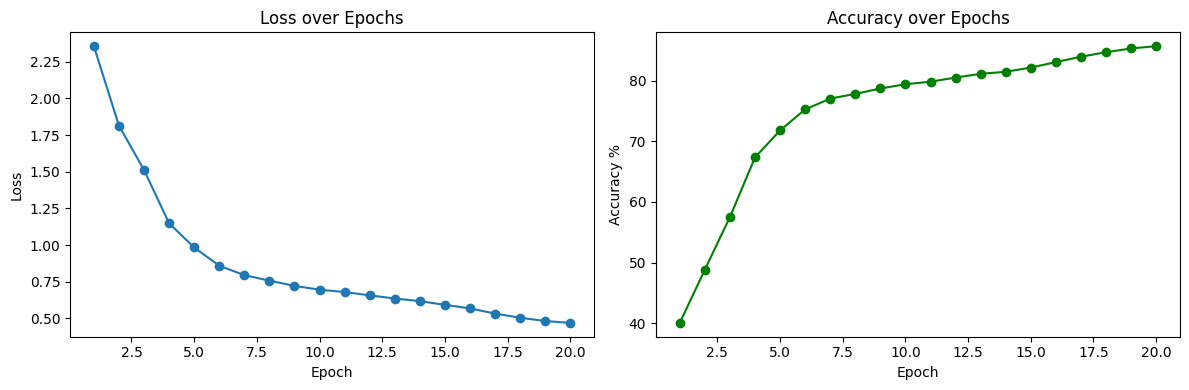

In [15]:
import matplotlib.pyplot as plt

num_epochs = 20
train_losses = []
train_accuracies = []

for epoch in range(num_epochs):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0
    
    for batch_idx, (spectrograms, labels) in enumerate(train_loader):
        spectrograms = spectrograms.to(device)
        labels = labels.to(device)
        
        outputs = model(spectrograms)
        loss = criterion(outputs, labels)
        
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item()
        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()
        
        if batch_idx % 200 == 0:
            print(f"Epoch {epoch+1} | Batch {batch_idx}/{len(train_loader)} | Loss: {running_loss/(batch_idx+1):.3f} | Accuracy: {100.*correct/total:.1f}%")
    
    # save epoch level loss and accuracy
    epoch_loss = running_loss / len(train_loader)
    epoch_acc = 100. * correct / total
    train_losses.append(epoch_loss)
    train_accuracies.append(epoch_acc)
    print(f"\nEpoch {epoch+1} complete | Loss: {epoch_loss:.3f} | Accuracy: {epoch_acc:.1f}%\n")

# plot after training
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(range(1, num_epochs+1), train_losses, marker='o')
ax1.set_title('Loss over Epochs')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')

ax2.plot(range(1, num_epochs+1), train_accuracies, marker='o', color='green')
ax2.set_title('Accuracy over Epochs')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Accuracy %')

plt.tight_layout()
plt.show()

In [21]:
model.eval()
correct = 0
total = 0

with torch.no_grad():
    for spectrograms, labels in test_loader:
        spectrograms = spectrograms.to(device)
        labels = labels.to(device)
        outputs = model(spectrograms)
        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()

print(f"Test Accuracy: {100.*correct/total:.1f}%")

Test Accuracy: 73.7%


In [22]:
torch.save(model.state_dict(), 'audio_cnn.pth')
print("Model saved")

Model saved
